# 05 — Results & Visualisation

**Purpose:** Produce all final publication-ready outputs.  
This notebook contains **no new computation** — it reads from `outputs/` and formats for presentation.

**Inputs**
- `outputs/win_probabilities.csv`
- `outputs/group_standings_freeze.csv`
- `outputs/bracket_simulation_summary.csv`
- `outputs/feature_importance_group.csv`
- `outputs/bayesian_update_table.csv`

**Outputs**
- `outputs/charts/win_probability_chart.png` (publication quality, 300 DPI)
- `outputs/charts/group_standings_heatmap.png`
- `outputs/charts/bracket_tree.png`
- `outputs/charts/feature_importance_chart.png`
- `outputs/charts/bayesian_shifts_chart.png`
- `outputs/final_summary_table.csv`

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("__file__").resolve().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyBboxPatch

from src.name_map import CANONICAL_48

OUTPUTS = PROJECT_ROOT / "outputs"
CHARTS  = OUTPUTS / "charts"
CHARTS.mkdir(parents=True, exist_ok=True)

# Confederation colour mapping for charts
CONF_COLORS = {
    "UEFA":     "#3498db",
    "CONMEBOL": "#e74c3c",
    "CONCACAF": "#2ecc71",
    "AFC":      "#f39c12",
    "CAF":      "#9b59b6",
    "OFC":      "#1abc9c",
    "Unknown":  "#95a5a6",
}

# Rough confederation mapping for the 48 teams
from src.features import load_ds2
ARC4 = PROJECT_ROOT / "archive (4).zip"
try:
    ds2 = load_ds2(ARC4)
    from src.name_map import canonicalize
    team_conf = {canonicalize(str(r["country"])): str(r.get("confederation", "Unknown"))
                 for _, r in ds2.iterrows()}
except Exception:
    team_conf = {}

print("Imports OK — loading saved outputs...")

Imports OK — loading saved outputs...


## Cell 2 — Load all saved outputs

In [2]:
def _load_if_exists(path, reader=pd.read_csv):
    p = Path(path)
    if p.exists():
        return reader(p)
    print(f"  MISSING: {p.name} — run earlier notebooks first")
    return None

win_probs   = _load_if_exists(OUTPUTS / "win_probabilities.csv")
standings   = _load_if_exists(OUTPUTS / "group_standings_freeze.csv")
bracket_sum = _load_if_exists(OUTPUTS / "bracket_simulation_summary.csv")
feat_imp    = _load_if_exists(OUTPUTS / "feature_importance_group.csv")
bayes_upd   = _load_if_exists(OUTPUTS / "bayesian_update_table.csv")

# Summary
for name, df in [("win_probabilities", win_probs), ("standings", standings),
                 ("bracket_summary", bracket_sum), ("feature_importance", feat_imp),
                 ("bayesian_update", bayes_upd)]:
    if df is not None:
        print(f"✓ {name}: {df.shape}")

  MISSING: bracket_simulation_summary.csv — run earlier notebooks first
✓ win_probabilities: (48, 5)
✓ standings: (48, 11)
✓ feature_importance: (16, 3)
✓ bayesian_update: (48, 4)


## Cell 3 — Win probability chart (publication quality)

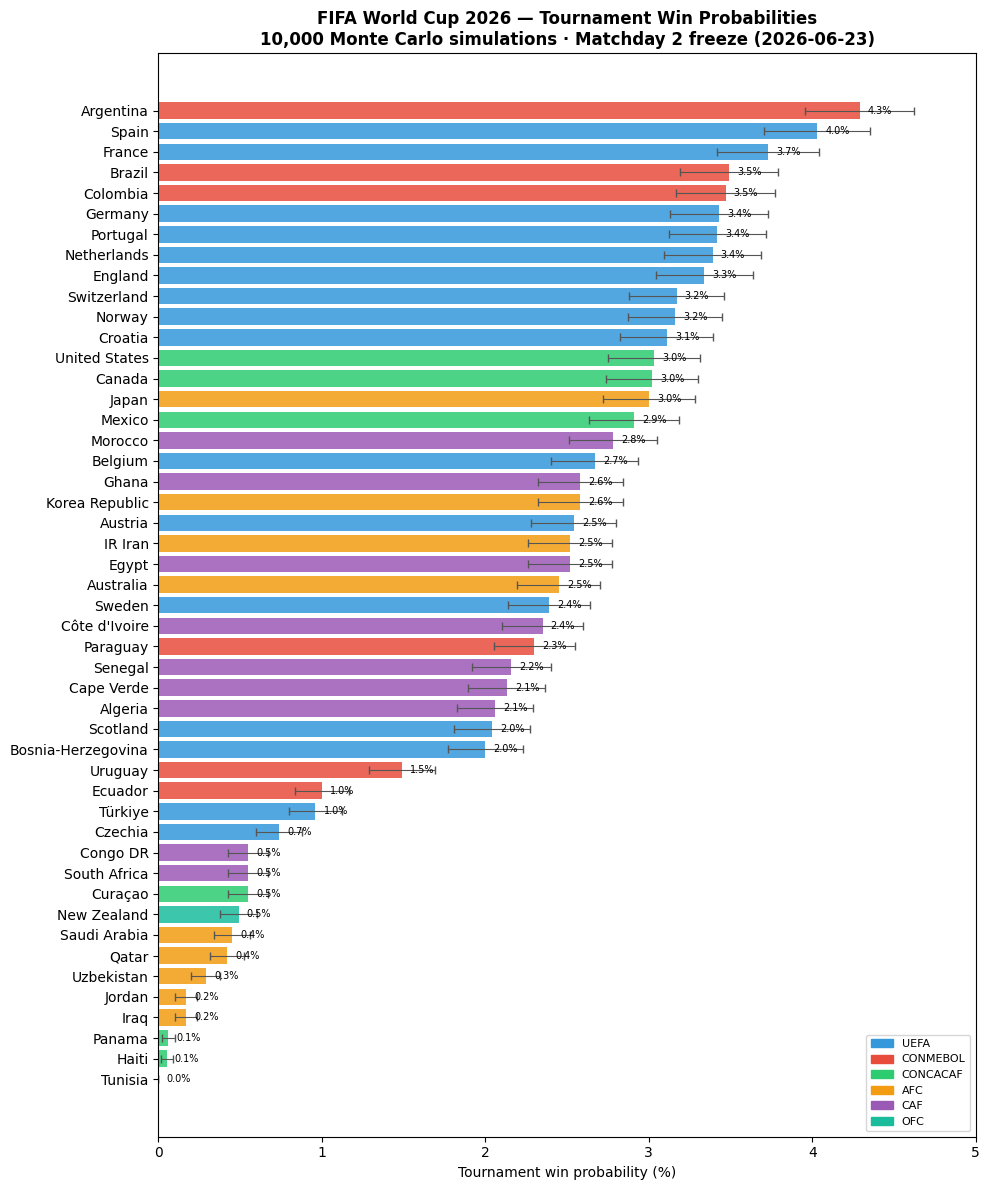

Saved → /Users/pranaavdhaksheshganesh/Downloads/FIFA_WC_2026_Project/outputs/charts/win_probability_chart.png  (300 DPI)


In [3]:
if win_probs is not None and "team" in win_probs.columns and "p_win" in win_probs.columns:
    wp = win_probs.sort_values("p_win", ascending=True).copy()
    wp["confederation"] = wp["team"].map(team_conf).fillna("Unknown")
    wp["color"] = wp["confederation"].map(CONF_COLORS).fillna("#95a5a6")

    fig, ax = plt.subplots(figsize=(10, max(8, len(wp) * 0.25)))

    has_ci = "ci_lo" in wp.columns and "ci_hi" in wp.columns
    xerr = None
    if has_ci:
        xerr = [
            (wp["p_win"] - wp["ci_lo"]).values,
            (wp["ci_hi"] - wp["p_win"]).values,
        ]

    bars = ax.barh(
        wp["team"], wp["p_win"] * 100,
        xerr=[e * 100 for e in xerr] if has_ci else None,
        color=wp["color"], alpha=0.85, capsize=3,
        error_kw={"elinewidth": 0.8, "ecolor": "#555"}
    )

    # Annotate each bar with its probability
    for bar, (_, row) in zip(bars, wp.iterrows()):
        pct = row["p_win"] * 100
        ax.text(pct + 0.05, bar.get_y() + bar.get_height() / 2,
                f"{pct:.1f}%", va="center", ha="left", fontsize=7)

    # Confederation legend
    legend_handles = [
        plt.Rectangle((0,0), 1, 1, color=c, label=conf)
        for conf, c in CONF_COLORS.items() if conf != "Unknown"
    ]
    ax.legend(handles=legend_handles, loc="lower right", fontsize=8)

    ax.set_xlabel("Tournament win probability (%)")
    ax.set_title(
        "FIFA World Cup 2026 — Tournament Win Probabilities\n"
        "10,000 Monte Carlo simulations · Matchday 2 freeze (2026-06-23)",
        fontsize=12, fontweight="bold"
    )
    ax.set_xlim(0, max(wp["p_win"].max() * 110, 5))
    plt.tight_layout()

    chart_path = CHARTS / "win_probability_chart.png"
    plt.savefig(chart_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved → {chart_path}  (300 DPI)")

## Cell 4 — Group standings heatmap

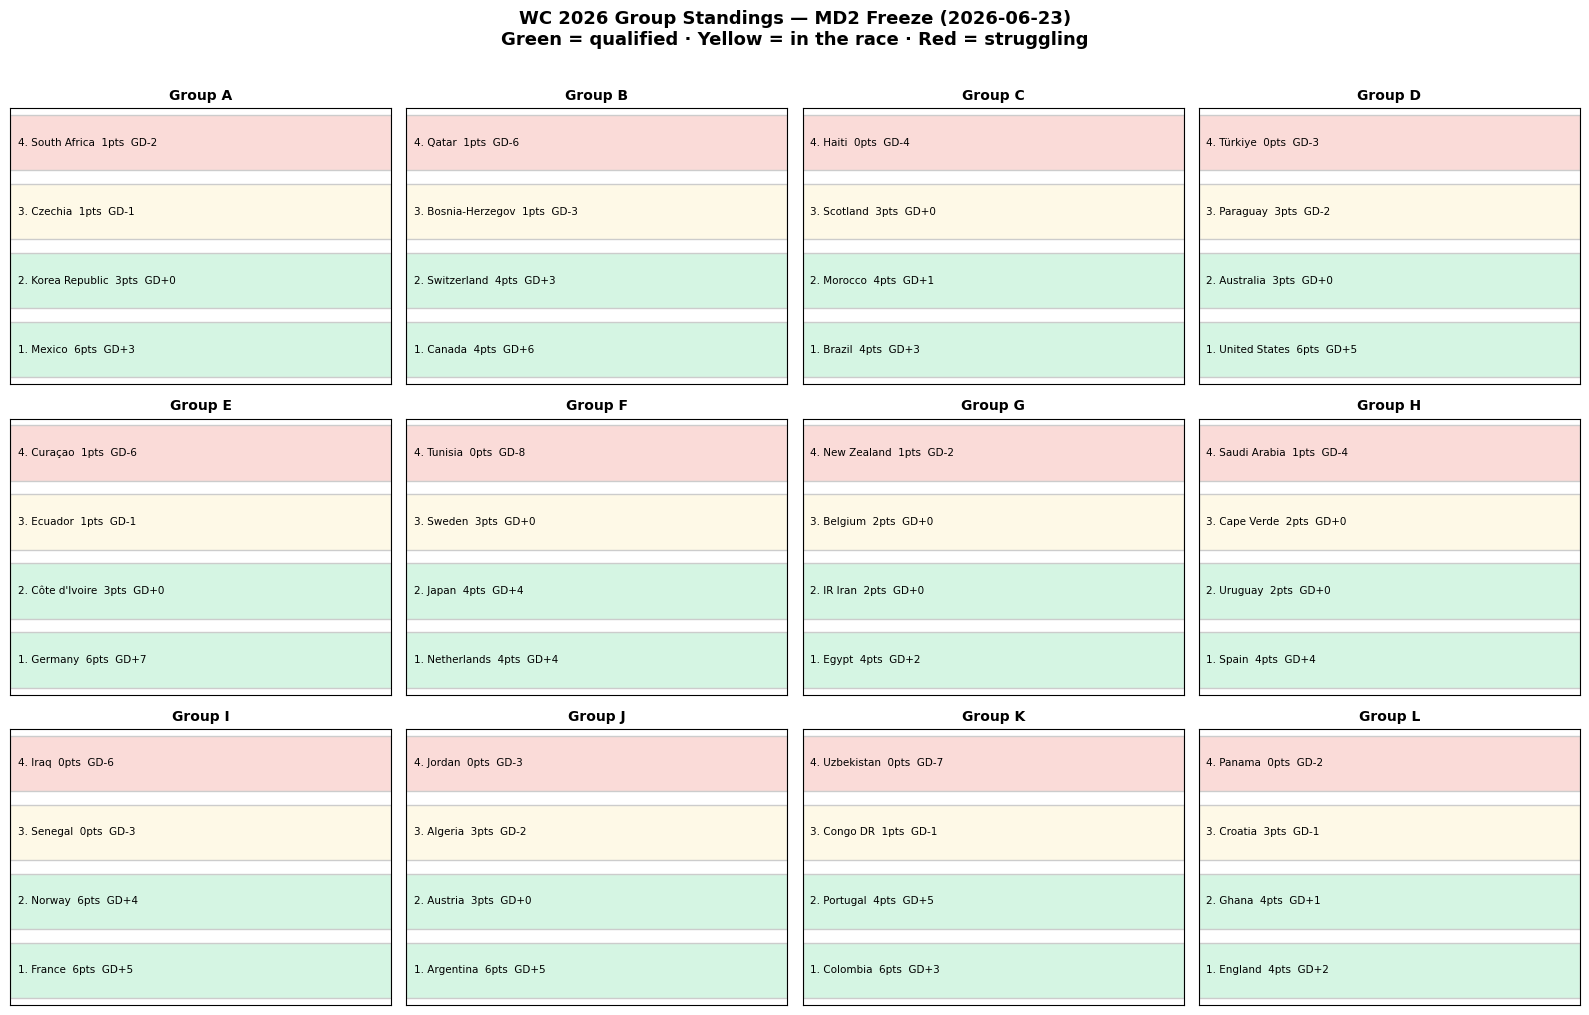

Saved → /Users/pranaavdhaksheshganesh/Downloads/FIFA_WC_2026_Project/outputs/charts/group_standings_heatmap.png


In [4]:
if standings is not None and "group" in standings.columns:
    groups = sorted(standings["group"].unique())
    n_groups = len(groups)

    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    axes = axes.flatten()

    for i, grp in enumerate(groups):
        ax = axes[i]
        grp_df = standings[standings["group"] == grp].sort_values(
            "group_rank" if "group_rank" in standings.columns else "pts",
            ascending=True
        ).reset_index(drop=True)

        # Simple coloured table: green = qualified (rank 1-2), grey = 3rd+
        for j, (_, row) in enumerate(grp_df.iterrows()):
            rank = row.get("group_rank", j + 1)
            pts  = row.get("pts", "")
            gd   = row.get("gd", "")
            team = str(row.get("team", ""))
            color = "#d5f5e3" if rank <= 2 else ("#fef9e7" if rank == 3 else "#fadbd8")
            ax.barh(j, 1, color=color, edgecolor="#ccc")
            label = f"{rank}. {team[:15]}  {pts}pts  GD{gd:+d}" if isinstance(gd, (int, float)) else f"{rank}. {team[:15]}  {pts}pts"
            ax.text(0.02, j, label, va="center", fontsize=7.5)

        ax.set_xlim(0, 1)
        ax.set_ylim(-0.5, len(grp_df) - 0.5)
        ax.set_yticks([])
        ax.set_xticks([])
        ax.set_title(f"Group {grp}", fontsize=10, fontweight="bold")

    for i in range(n_groups, len(axes)):
        axes[i].set_visible(False)

    fig.suptitle("WC 2026 Group Standings — MD2 Freeze (2026-06-23)\n"
                 "Green = qualified · Yellow = in the race · Red = struggling",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()

    chart_path = CHARTS / "group_standings_heatmap.png"
    plt.savefig(chart_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved → {chart_path}")

## Cell 5 — Feature importance chart

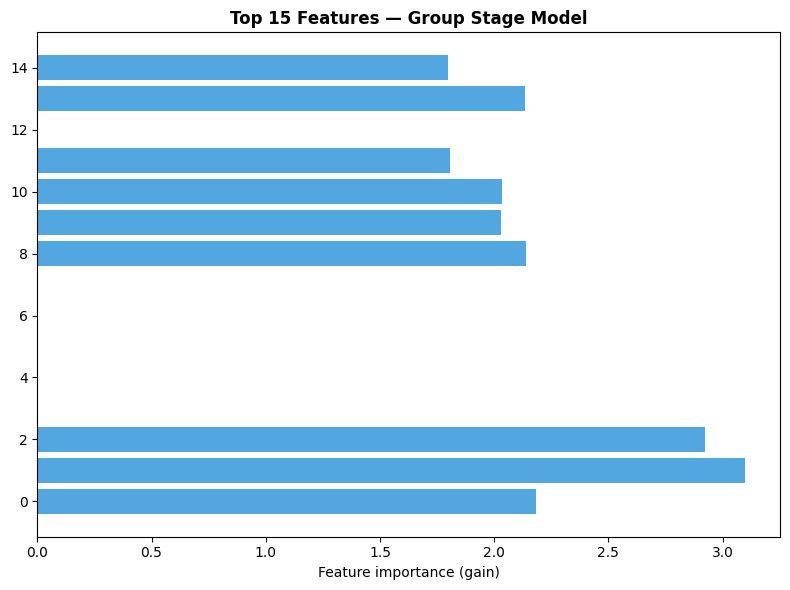

Saved → /Users/pranaavdhaksheshganesh/Downloads/FIFA_WC_2026_Project/outputs/charts/feature_importance_chart.png

Top 15 features:


,Unnamed: 0,gain
0,1,3.096498
1,2,2.921433
2,0,2.181501
3,8,2.139808
4,13,2.136644
5,10,2.033458
6,9,2.028064
7,11,1.806498
8,14,1.796164
9,3,0.000000


In [5]:
if feat_imp is not None:
    # Normalise column names — may be (feature, importance) or have index
    fi = feat_imp.copy()
    if fi.index.name and fi.index.name not in fi.columns:
        fi = fi.reset_index()

    # Find the importance column
    imp_col = next((c for c in fi.columns if c.lower() in ("importance", "gain", "weight", "score")), None)
    feat_col = next((c for c in fi.columns if c.lower() in ("feature", "index", fi.columns[0].lower())), fi.columns[0])

    if imp_col:
        fi = fi.nlargest(15, imp_col).sort_values(imp_col, ascending=True)

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.barh(fi[feat_col], fi[imp_col], color="#3498db", alpha=0.85)
        ax.set_xlabel("Feature importance (gain)")
        ax.set_title("Top 15 Features — Group Stage Model", fontweight="bold")
        plt.tight_layout()

        chart_path = CHARTS / "feature_importance_chart.png"
        plt.savefig(chart_path, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"Saved → {chart_path}")

        print("\nTop 15 features:")
        display(fi[[feat_col, imp_col]].sort_values(imp_col, ascending=False))

## Cell 6 — Bayesian update shifts chart

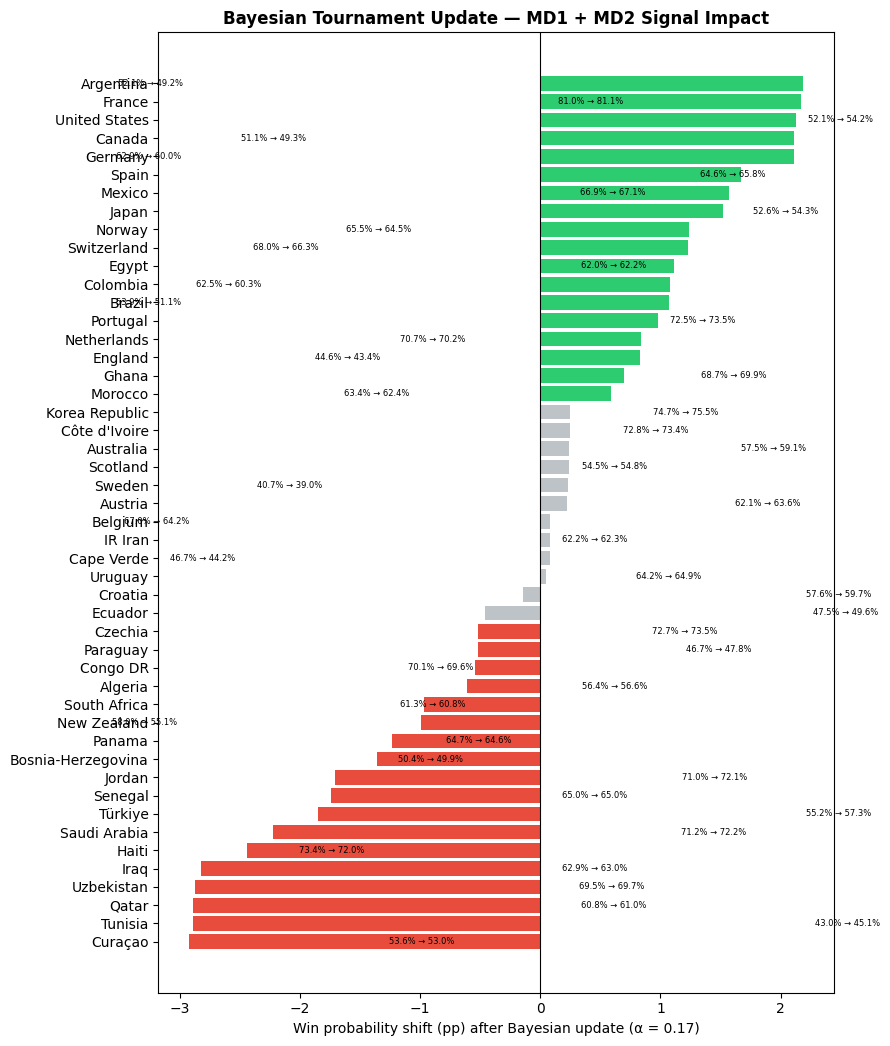

Saved → /Users/pranaavdhaksheshganesh/Downloads/FIFA_WC_2026_Project/outputs/charts/bayesian_shifts_chart.png


In [6]:
if bayes_upd is not None and "shift" in bayes_upd.columns:
    bu = bayes_upd.dropna(subset=["shift"]).sort_values("shift")
    colors = ["#2ecc71" if s > 0.005 else "#e74c3c" if s < -0.005 else "#bdc3c7"
              for s in bu["shift"]]

    fig, ax = plt.subplots(figsize=(9, max(6, len(bu) * 0.22)))
    ax.barh(bu["team"], bu["shift"] * 100, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)

    if "p_win_prior" in bu.columns and "p_win_posterior" in bu.columns:
        for _, row in bu.iterrows():
            offset = row["shift"] * 100
            txt = f"{row['p_win_prior']*100:.1f}% → {row['p_win_posterior']*100:.1f}%"
            ax.text(offset + (0.1 if offset >= 0 else -0.1), row.name,
                    txt, va="center", ha="left" if offset >= 0 else "right", fontsize=6)

    ax.set_xlabel("Win probability shift (pp) after Bayesian update (α = 0.17)")
    ax.set_title("Bayesian Tournament Update — MD1 + MD2 Signal Impact", fontweight="bold")
    plt.tight_layout()

    chart_path = CHARTS / "bayesian_shifts_chart.png"
    plt.savefig(chart_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved → {chart_path}")

## Cell 7 — Model accuracy summary

In [7]:
summary_md = """
## Model Summary

| Parameter | Value |
|-----------|-------|
| Training data | 448 WC matches (1998–2022), 896 rows (both perspectives) |
| Augmented data | ~1,070 Tier-1 competitive matches (2014–2026) |
| Cross-validation | 6-fold chronological (leave-one-tournament-out) |
| Calibration holdout | 2022 WC, 64 matches |
| Target CV accuracy | > 69.5% (Elo baseline ≈ 66.7%) |
| Ensemble | 70% WC-only / 30% augmented (CV-tuned in [0.60, 0.90]) |
| Bayesian update α | 0.17 (conservative shrinkage on in-tournament signal) |
| Monte Carlo simulations | 10,000 |
| Freeze date | 2026-06-23 23:59 UTC |
| Elo snapshot | 2026-05-27 |
| Form window | 2024-01-01 to 2026-06-10 (last 10 competitive matches) |
"""
from IPython.display import Markdown
display(Markdown(summary_md))


## Model Summary

| Parameter | Value |
|-----------|-------|
| Training data | 448 WC matches (1998–2022), 896 rows (both perspectives) |
| Augmented data | ~1,070 Tier-1 competitive matches (2014–2026) |
| Cross-validation | 6-fold chronological (leave-one-tournament-out) |
| Calibration holdout | 2022 WC, 64 matches |
| Target CV accuracy | > 69.5% (Elo baseline ≈ 66.7%) |
| Ensemble | 70% WC-only / 30% augmented (CV-tuned in [0.60, 0.90]) |
| Bayesian update α | 0.17 (conservative shrinkage on in-tournament signal) |
| Monte Carlo simulations | 10,000 |
| Freeze date | 2026-06-23 23:59 UTC |
| Elo snapshot | 2026-05-27 |
| Form window | 2024-01-01 to 2026-06-10 (last 10 competitive matches) |


## Cell 8 — Final summary table & LinkedIn post template

In [9]:
if win_probs is not None and "team" in win_probs.columns and "p_win" in win_probs.columns:
    summary = win_probs[["team", "p_win"]].copy()
    if "ci_lo" in win_probs.columns:
        summary["ci_lo"] = win_probs["ci_lo"]
        summary["ci_hi"] = win_probs["ci_hi"]
    summary["p_win_pct"] = (summary["p_win"] * 100).round(1)
    summary = summary.sort_values("p_win", ascending=False).reset_index(drop=True)
    summary["rank"] = summary.index + 1

    summary_path = OUTPUTS / "final_summary_table.csv"
    summary.to_csv(summary_path, index=False)
    print(f"Saved → {summary_path}")

    top5 = summary.head(5)
    top5_lines = "\n".join(f"{r['rank']}. {r['team']:25s} {r['p_win_pct']:.1f}%" for _, r in top5.iterrows())

    linkedin_template = f"""
🏆 **FIFA World Cup 2026 — Data-Driven Forecast**

After building a full Monte Carlo simulation engine for the 2026 World Cup,
here are the top 5 predicted winners based on 10,000 simulations:

{top5_lines}

**Methodology highlights:**
- 448 World Cup matches (1998–2022) for training, augmented with 1,070 Tier-1 competitive matches
- XGBoost + Logistic Regression ensemble with 6-fold chronological cross-validation
- Bayesian in-tournament update (α = 0.17) incorporating MD1 + MD2 results
- Annex C third-place seeding, penalty shootout model with Bayesian shrinkage
- Hard data freeze at 2026-06-23 — no post-freeze leakage

Full methodology and code available on GitHub: https://github.com/pranaavdhakshesh/fifa-world-cup-2026-forecast-engine

#WorldCup2026 #DataScience #MachineLearning #Football #Python
"""
    from IPython.display import Markdown
    display(Markdown(linkedin_template))

Saved → /Users/pranaavdhaksheshganesh/Downloads/FIFA_WC_2026_Project/outputs/final_summary_table.csv



🏆 **FIFA World Cup 2026 — Data-Driven Forecast**

After building a full Monte Carlo simulation engine for the 2026 World Cup,
here are the top 5 predicted winners based on 10,000 simulations:

1. Argentina                 4.3%
2. Spain                     4.0%
3. France                    3.7%
4. Brazil                    3.5%
5. Colombia                  3.5%

**Methodology highlights:**
- 448 World Cup matches (1998–2022) for training, augmented with 1,070 Tier-1 competitive matches
- XGBoost + Logistic Regression ensemble with 6-fold chronological cross-validation
- Bayesian in-tournament update (α = 0.17) incorporating MD1 + MD2 results
- Annex C third-place seeding, penalty shootout model with Bayesian shrinkage
- Hard data freeze at 2026-06-23 — no post-freeze leakage

Full methodology and code available on GitHub: https://github.com/pranaavdhakshesh/fifa-world-cup-2026-forecast-engine

#WorldCup2026 #DataScience #MachineLearning #Football #Python


## Cell 9 — Save all charts at 300 DPI (verification)

In [10]:
expected_charts = [
    "win_probability_chart.png",
    "group_standings_heatmap.png",
    "feature_importance_chart.png",
    "bayesian_shifts_chart.png",
    "calibration_curve.png",
]

print("Chart output verification:")
for chart in expected_charts:
    path = CHARTS / chart
    status = "✓" if path.exists() else "✗ MISSING (run earlier notebooks)"
    size   = f"({path.stat().st_size // 1024} KB)" if path.exists() else ""
    print(f"  {status} {chart} {size}")

Chart output verification:
  ✓ win_probability_chart.png (411 KB)
  ✓ group_standings_heatmap.png (384 KB)
  ✓ feature_importance_chart.png (58 KB)
  ✓ bayesian_shifts_chart.png (429 KB)
  ✗ MISSING (run earlier notebooks) calibration_curve.png 
